# 12 · CNN Tanítása – MobileNetV3-Small Transfer Learning

**Adatforrás:** `X_images.npy` (N × 224 × 224 × 3, float32 [0,1] RGB)  
**Architektúra:** MobileNetV3-Small, ImageNet pretraining  
**Protokoll:** Phase A (frozen backbone) → Phase B (unfreeze utolsó 3 blokk)  
**Kimenet:** élő loss/accuracy görbe, hiba-analízis, `.pth` checkpoint

> **Előfeltétel:** Futtasd le előbb a `src/dataset_generator.py`-t:
> ```
> python -m src.dataset_generator
> ```

In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  ADATFÁJL GUARD – futtasd ezt a cellát legelőször!                  ║
# ║  Ha hiányoznak az npy fájlok, automatikusan legenerálja őket.       ║
# ║  A cella NEM enged tovább, amíg az export be nem fejeződik.         ║
# ╚══════════════════════════════════════════════════════════════════════╝
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

from IPython.display import display, HTML
from src.config import PATHS

_FEATURES_DIR = PATHS["data"] / "features"
_REQUIRED = {
    "X_basic.npy":    "56-dim feature vektorok",
    "X_inlay.npy":    "60-dim inlay-bővített vektorok",
    "X_images.npy":   "224×224 normalizált képek",
    "y.npy":          "osztálycímkék",
    "splits.npy":     "train/val/test split",
    "class_names.npy":"osztálynevek",
}

_missing = [k for k in _REQUIRED if not (_FEATURES_DIR / k).exists()]

if _missing:
    display(HTML(
        "<div style='border:2px solid #f39c12; border-radius:6px; padding:12px; "
        "background:#fef9e7; font-family:monospace'>"
        "<b>⏳ Hiányzó adatfájlok:</b><br>"
        + "".join(f"&nbsp;&nbsp;• {k} – {_REQUIRED[k]}<br>" for k in _missing)
        + "<br><b>V14 pipeline export indul...</b> (~5–10 perc, képenként látható a haladás)"
        "</div>"
    ))

    from src.dataset_generator import export_dataset
    out = export_dataset(verbose=True)

    import numpy as np
    rows = ""
    for k in _REQUIRED:
        a = np.load(_FEATURES_DIR / k, allow_pickle=True)
        rows += f"<tr><td>{k}</td><td>{a.shape}</td><td>{a.dtype}</td></tr>"

    display(HTML(
        "<div style='border:2px solid #27ae60; border-radius:6px; padding:12px; "
        "background:#eafaf1; font-family:monospace; margin-top:8px'>"
        "<b>✅ Export kész!</b> Folytasd a következő cellával.<br><br>"
        "<table style='border-collapse:collapse'>"
        "<tr><th style='padding:2px 12px'>Fájl</th>"
        "<th style='padding:2px 12px'>Shape</th>"
        "<th style='padding:2px 12px'>Dtype</th></tr>"
        + rows + "</table></div>"
    ))
else:
    import numpy as np
    rows = ""
    for k in _REQUIRED:
        a = np.load(_FEATURES_DIR / k, allow_pickle=True)
        rows += f"<tr><td>{k}</td><td>{a.shape}</td><td>{a.dtype}</td></tr>"

    display(HTML(
        "<div style='border:2px solid #2980b9; border-radius:6px; padding:12px; "
        "background:#eaf4fb; font-family:monospace'>"
        "<b>✅ Minden adatfájl megtalálható</b> – export kihagyva.<br><br>"
        "<table style='border-collapse:collapse'>"
        "<tr><th style='padding:2px 12px'>Fájl</th>"
        "<th style='padding:2px 12px'>Shape</th>"
        "<th style='padding:2px 12px'>Dtype</th></tr>"
        + rows + "</table></div>"
    ))


Fájl,Shape,Dtype
X_basic.npy,"(297, 56)",float32
X_inlay.npy,"(297, 60)",float32
X_images.npy,"(297, 224, 224, 3)",float32
y.npy,"(297,)",int64
splits.npy,"(297,)",object
class_names.npy,"(8,)",<U7


In [2]:
import sys, re
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from IPython.display import clear_output, display
import torchvision.transforms.functional as TF
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from src.config import CFG, PATHS
from src.models import (
    build_model, freeze_backbone, unfreeze_last_blocks, count_parameters,
)
from src.train import EarlyStopping, train_one_epoch, evaluate
from src.dataset import compute_class_weights

FEATURES_DIR = PATHS["data"] / "features"
MODEL_DIR    = PATHS["root"] / "models"
CKPT_DIR     = PATHS["checkpoint_dir"]
MODEL_DIR.mkdir(exist_ok=True)
CKPT_DIR.mkdir(exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA T500


## 1 · Adatbetöltés

In [3]:
X_images = np.load(FEATURES_DIR / "X_images.npy")   # (N, 224, 224, 3) float32 [0,1]
y_arr    = np.load(FEATURES_DIR / "y.npy")
splits   = np.load(FEATURES_DIR / "splits.npy", allow_pickle=True)
classes  = list(np.load(FEATURES_DIR / "class_names.npy", allow_pickle=True))
N_CLASSES = len(classes)

tr_mask = splits == "train"
va_mask = splits == "val"
te_mask = splits == "test"

print(f"X_images : {X_images.shape}  dtype={X_images.dtype}")
print(f"y        : {y_arr.shape}     osztályok={classes}")
print(f"Train={tr_mask.sum()}  Val={va_mask.sum()}  Test={te_mask.sum()}")
print(f"Pixel érték tartomány: [{X_images.min():.3f}, {X_images.max():.3f}]")

X_images : (297, 224, 224, 3)  dtype=float32
y        : (297,)     osztályok=[np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('No hand')]
Train=207  Val=45  Test=45
Pixel érték tartomány: [0.000, 1.000]


## 2 · Mintaképek – 4×4 rács

Véletlenszerű, normalizált 224×224 minták akkordcímkével.

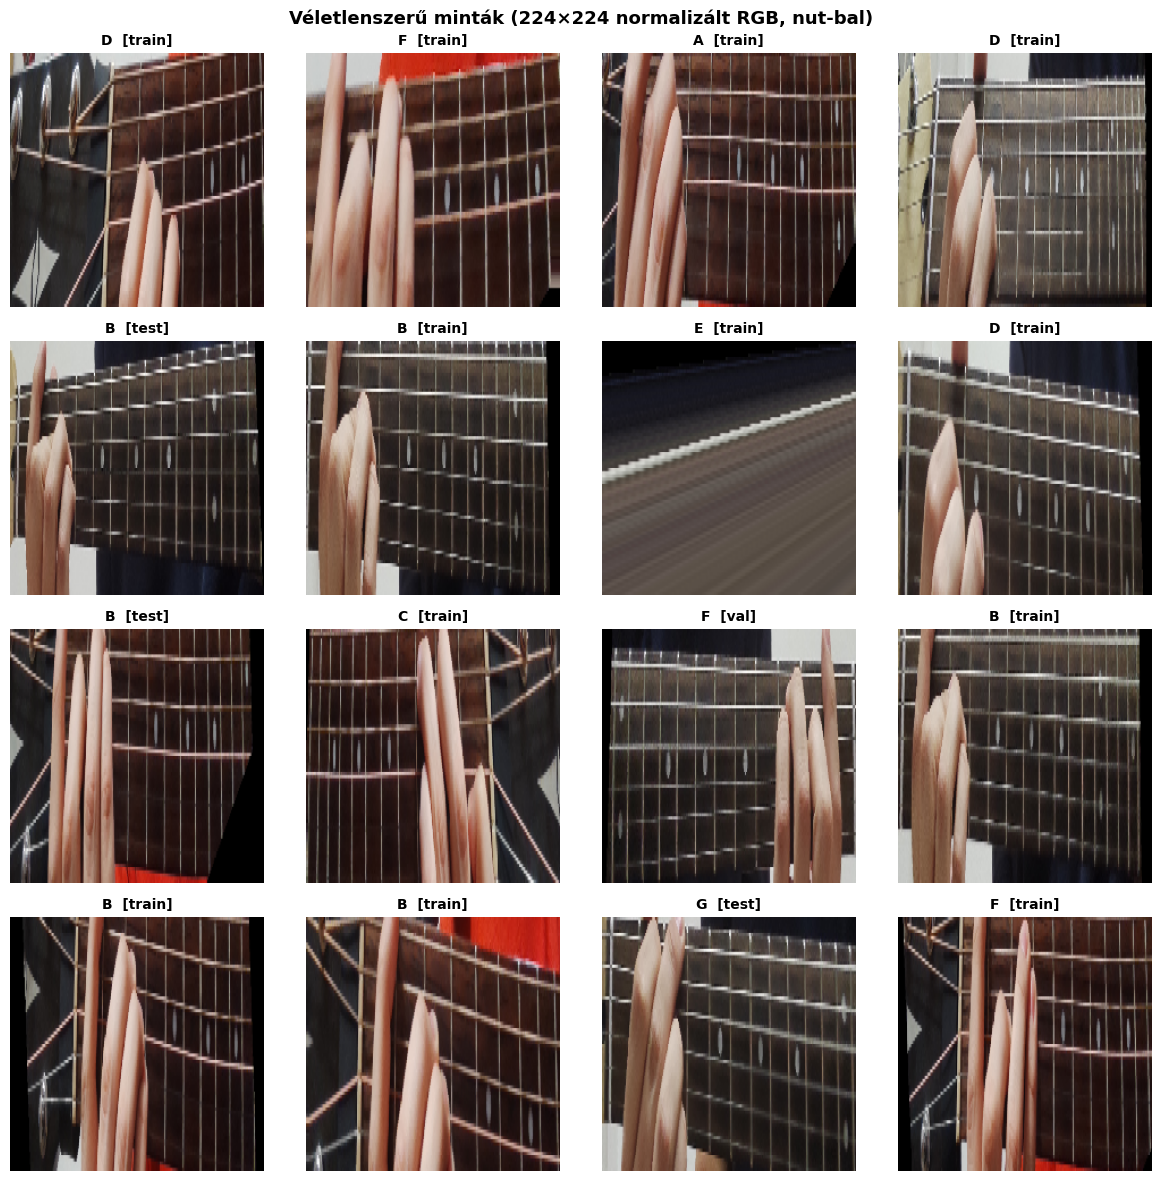

In [4]:
rng = np.random.RandomState(SEED)
idx = rng.choice(len(y_arr), size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, i in zip(axes.flatten(), idx):
    ax.imshow(X_images[i])   # float32 [0,1] RGB
    split_lbl = splits[i]
    ax.set_title(f"{classes[y_arr[i]]}  [{split_lbl}]",
                 fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle("Véletlenszerű minták (224×224 normalizált RGB, nut-bal)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Egy minta per osztály

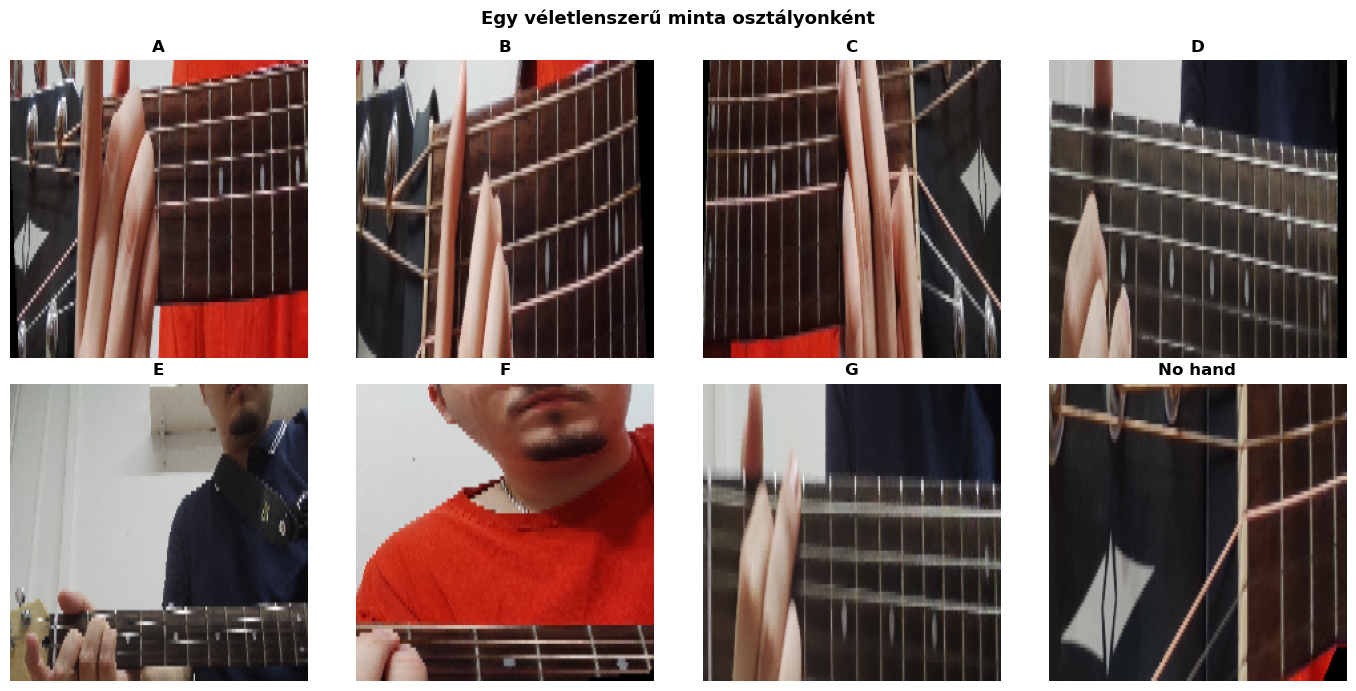

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, cls_i in zip(axes.flatten(), range(N_CLASSES)):
    idxs = np.where(y_arr == cls_i)[0]
    sample_i = rng.choice(idxs)
    ax.imshow(X_images[sample_i])
    ax.set_title(f"{classes[cls_i]}", fontsize=12, fontweight="bold")
    ax.axis("off")

plt.suptitle("Egy véletlenszerű minta osztályonként",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3 · Dataset & DataLoader

`NpyImageDataset`: az `X_images.npy` numpy tömböt olvas tensor-rá alakítva, opcionális augmentációval és ImageNet normalizálással.

In [6]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


class NpyImageDataset(Dataset):
    """X_images.npy-alapú dataset augmentációval + ImageNet normalizálással.

    X: (N, H, W, 3) float32 [0,1] → (3, H, W) tensor; ImageNet-norm alkalmazva.
    Augmentáció (train): enyhe forgatás, fényerő/kontraszt jitter, hflip.
    """

    def __init__(self, X: np.ndarray, y: np.ndarray, augment: bool = False):
        # (N, H, W, 3) → (N, 3, H, W)
        self.X = torch.from_numpy(X.transpose(0, 3, 1, 2)).float()
        self.y = torch.from_numpy(y).long()
        self.augment = augment

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, i: int):
        x = self.X[i].clone()
        if self.augment:
            # Enyhe forgatás ±15°
            angle = float(torch.empty(1).uniform_(-15.0, 15.0))
            x = TF.rotate(x, angle)
            # Fényerő jitter [0.75, 1.30]
            x = TF.adjust_brightness(
                x, float(torch.empty(1).uniform_(0.75, 1.30)))
            # Kontraszt jitter [0.80, 1.20]
            x = TF.adjust_contrast(
                x, float(torch.empty(1).uniform_(0.80, 1.20)))
            # Vízszintes tükrözés 50%
            if torch.rand(1).item() > 0.5:
                x = TF.hflip(x)
        # ImageNet normalizálás
        x = (x - IMAGENET_MEAN) / IMAGENET_STD
        return x, self.y[i]


BATCH = CFG["batch_size"]

train_ds = NpyImageDataset(X_images[tr_mask], y_arr[tr_mask], augment=True)
val_ds   = NpyImageDataset(X_images[va_mask], y_arr[va_mask], augment=False)
test_ds  = NpyImageDataset(X_images[te_mask], y_arr[te_mask], augment=False)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                      num_workers=0, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=0)

class_weights = compute_class_weights(y_arr[tr_mask], N_CLASSES, device=device)
print(f"Batch méret  : {BATCH}")
print(f"Train batches: {len(train_dl)}")
print(f"Val   batches: {len(val_dl)}")
print(f"Test  batches: {len(test_dl)}")
print(f"class_weights: {class_weights.cpu().numpy().round(3)}")

Batch méret  : 16
Train batches: 12
Val   batches: 3
Test  batches: 3
class_weights: [1.125 0.663 0.784 0.835 1.176 0.761 1.725 2.588]


## 4 · Modell – MobileNetV3-Small

ImageNet-pretrained backbone, cserált classifier head (8 akkordosztályhoz).

In [7]:
MODEL_NAME = "mobilenet_v3_small"
model = build_model(MODEL_NAME, num_classes=N_CLASSES).to(device)

total, trainable = count_parameters(model)
print(f"Architektúra  : {MODEL_NAME}")
print(f"Összes param  : {total:,}")
print(f"Tanítható (init): {trainable:,}")
print(f"Backbone      : model.features")
print(f"Head          : model.classifier  (utolsó Linear → {N_CLASSES} out)")
print(f"\nClassifier:")
print(model.classifier)

Architektúra  : mobilenet_v3_small
Összes param  : 1,526,056
Tanítható (init): 1,526,056
Backbone      : model.features
Head          : model.classifier  (utolsó Linear → 8 out)

Classifier:
Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=8, bias=True)
)


## 5 · Training Loop

**Phase A** – frozen backbone, csak a classifier head tanítható (gyors konvergencia)  
**Phase B** – utolsó 3 backbone blokk + head felolvad (fine-tune)

Mindkét fázisban **EarlyStopping** `val_loss` alapján, élőben frissülő Loss + Accuracy görbékkel.

In [8]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Tanítási előzmény tárolása mindkét fázishoz
history: dict[str, list] = {
    "phase":   [],
    "ep":      [],
    "tr_loss": [],
    "tr_acc":  [],
    "vl_loss": [],
    "vl_acc":  [],
}


def _update_plot() -> None:
    """Élőben frissülő loss + accuracy görbe (clear_output alapú)."""
    if len(history["ep"]) < 2:
        return
    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    colors = {"A": "#2196F3", "B": "#FF9800"}

    for ph in ("A", "B"):
        idx = [i for i, p in enumerate(history["phase"]) if p == ph]
        if not idx:
            continue
        eps     = [history["ep"][i]      for i in idx]
        tr_loss = [history["tr_loss"][i] for i in idx]
        vl_loss = [history["vl_loss"][i] for i in idx]
        tr_acc  = [history["tr_acc"][i]  for i in idx]
        vl_acc  = [history["vl_acc"][i]  for i in idx]
        c = colors[ph]
        ax1.plot(eps, tr_loss, "--", color=c, alpha=0.55, label=f"Phase-{ph} train")
        ax1.plot(eps, vl_loss, "-",  color=c,              label=f"Phase-{ph} val")
        ax2.plot(eps, tr_acc,  "--", color=c, alpha=0.55, label=f"Phase-{ph} train")
        ax2.plot(eps, vl_acc,  "-",  color=c,              label=f"Phase-{ph} val")

    last_va = history["vl_acc"][-1]
    ax1.set_title("Cross-Entropy Loss");  ax1.set_xlabel("Epoch"); ax1.legend(fontsize=8)
    ax2.set_title(f"Accuracy (utolsó val={last_va:.3f})"); ax2.set_xlabel("Epoch")
    ax2.set_ylim(0, 1.05)
    for ax in (ax1, ax2):
        ax.grid(alpha=0.3)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

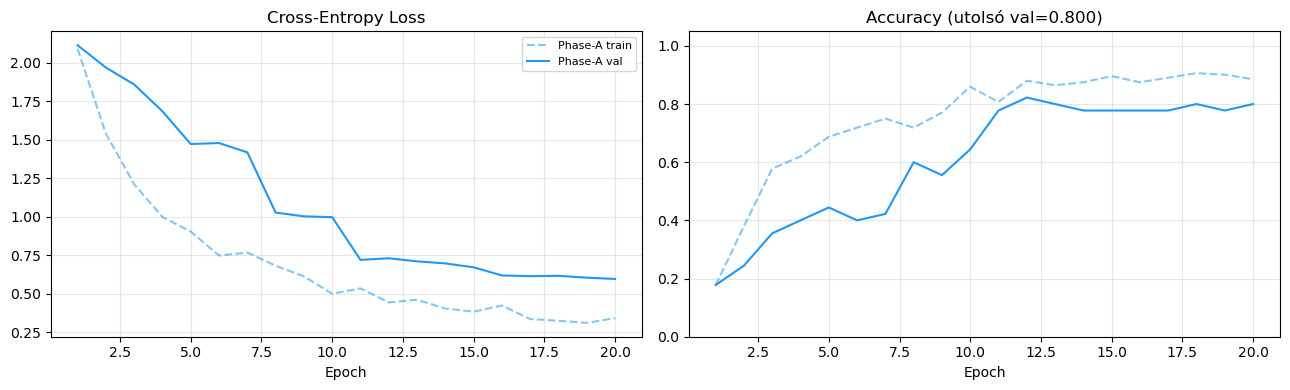

  Best model restored (val_loss=0.5968)

Phase A kész.  Best val_loss=0.5968


In [9]:
# ── Phase A: frozen backbone ──────────────────────────────────────────────
freeze_backbone(model, MODEL_NAME)
_, trainable_a = count_parameters(model)
print(f"[Phase A] tanítható paraméter: {trainable_a:,}")

EPOCHS_A = CFG["epochs_a"]
PATIENCE  = CFG["patience"]

opt_a = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG["lr_phase_a"], weight_decay=1e-4,
)
sch_a  = CosineAnnealingLR(opt_a, T_max=EPOCHS_A, eta_min=1e-5)
es_a   = EarlyStopping(patience=PATIENCE,
                       ckpt_path=CKPT_DIR / "nb12_phA.pth")

for ep in range(1, EPOCHS_A + 1):
    tr_loss, tr_acc        = train_one_epoch(model, train_dl, criterion, opt_a, device)
    vl_loss, vl_acc, _, _  = evaluate(model, val_dl, criterion, device)
    sch_a.step()

    history["phase"].append("A");  history["ep"].append(ep)
    history["tr_loss"].append(tr_loss); history["tr_acc"].append(tr_acc)
    history["vl_loss"].append(vl_loss); history["vl_acc"].append(vl_acc)
    _update_plot()

    if es_a.step(vl_loss, model):
        print(f"  Phase A early stop @ epoch {ep}")
        break

es_a.restore_best(model)
print(f"\nPhase A kész.  Best val_loss={es_a.best_loss:.4f}")

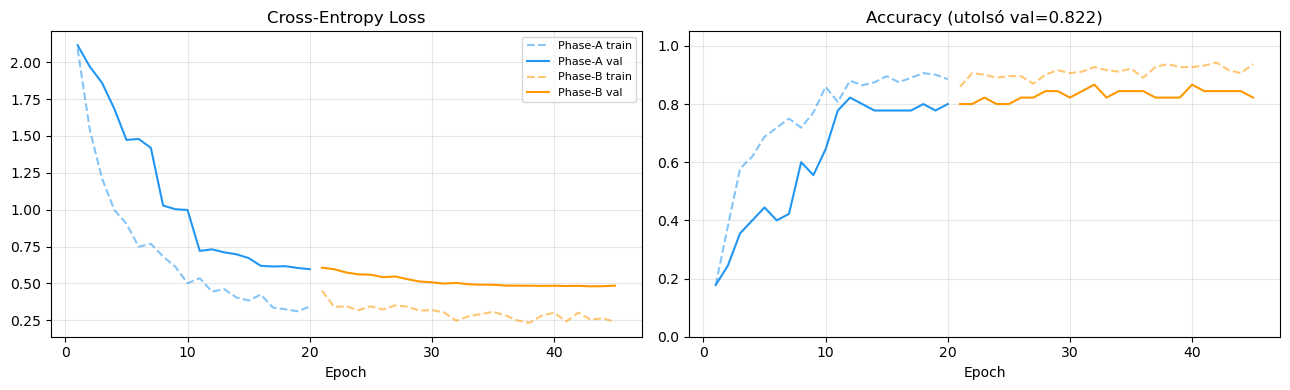

  Best model restored (val_loss=0.4804)

Phase B kész.  Best val_loss=0.4804


In [10]:
# ── Phase B: unfreeze utolsó 3 backbone blokk ────────────────────────────
unfreeze_last_blocks(model, MODEL_NAME)
_, trainable_b = count_parameters(model)
print(f"[Phase B] tanítható paraméter: {trainable_b:,}")

EPOCHS_B = CFG["epochs_b"]
ep_offset = len(history["ep"])

opt_b = AdamW([
    {"params": model.features.parameters(),
     "lr": CFG["lr_phase_b_backbone"]},
    {"params": model.classifier.parameters(),
     "lr": CFG["lr_phase_b_head"]},
], weight_decay=1e-4)
sch_b  = CosineAnnealingLR(opt_b, T_max=EPOCHS_B, eta_min=1e-6)
es_b   = EarlyStopping(patience=PATIENCE,
                       ckpt_path=CKPT_DIR / "nb12_phB.pth")

for ep in range(1, EPOCHS_B + 1):
    tr_loss, tr_acc        = train_one_epoch(model, train_dl, criterion, opt_b, device)
    vl_loss, vl_acc, _, _  = evaluate(model, val_dl, criterion, device)
    sch_b.step()

    history["phase"].append("B");  history["ep"].append(ep_offset + ep)
    history["tr_loss"].append(tr_loss); history["tr_acc"].append(tr_acc)
    history["vl_loss"].append(vl_loss); history["vl_acc"].append(vl_acc)
    _update_plot()

    if es_b.step(vl_loss, model):
        print(f"  Phase B early stop @ epoch {ep}")
        break

es_b.restore_best(model)
print(f"\nPhase B kész.  Best val_loss={es_b.best_loss:.4f}")

## 6 · Test Kiértékelés

In [11]:
te_loss, te_acc, te_preds, te_labels = evaluate(model, test_dl, criterion, device)

print(f"Test loss : {te_loss:.4f}")
print(f"Test acc  : {te_acc:.4f}  ({te_acc:.1%})")
print()
print(classification_report(te_labels, te_preds,
                             target_names=classes,
                             zero_division=0))

Test loss : 0.4810
Test acc  : 0.8000  (80.0%)

              precision    recall  f1-score   support

           A       1.00      0.80      0.89         5
           B       0.80      0.89      0.84         9
           C       0.86      0.86      0.86         7
           D       1.00      1.00      1.00         7
           E       0.50      0.75      0.60         4
           F       0.50      0.29      0.36         7
           G       0.80      1.00      0.89         4
     No hand       1.00      1.00      1.00         2

    accuracy                           0.80        45
   macro avg       0.81      0.82      0.81        45
weighted avg       0.80      0.80      0.79        45



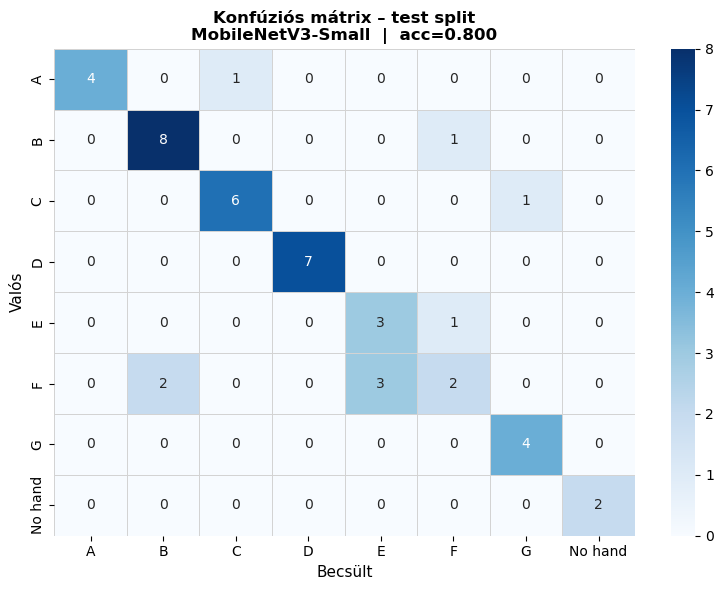

In [12]:
cm = confusion_matrix(te_labels, te_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", ax=ax,
    xticklabels=classes, yticklabels=classes,
    cmap="Blues", linewidths=0.4, linecolor="lightgray",
    cbar=True,
)
ax.set_xlabel("Becsült", fontsize=11)
ax.set_ylabel("Valós", fontsize=11)
ax.set_title(
    f"Konfúziós mátrix – test split\n"
    f"MobileNetV3-Small  |  acc={te_acc:.3f}",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## 7 · Hiba-analízis

Azok a test-képek, ahol a modell **legnagyobb confidence-szel tévedett** (predicted vs. actual).

In [13]:
model.eval()
all_probs:  list[np.ndarray] = []
all_preds_:  list[int]        = []
all_labels_: list[int]        = []
all_orig_i:  list[int]        = []

te_orig_indices = np.where(te_mask)[0]   # pozíciók az X_images tömbben

batch_start = 0
with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(device)
        probs = torch.softmax(model(xb), dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)
        n = len(yb)
        all_probs.extend(probs)
        all_preds_.extend(preds.tolist())
        all_labels_.extend(yb.numpy().tolist())
        all_orig_i.extend(te_orig_indices[batch_start:batch_start + n].tolist())
        batch_start += n

all_probs   = np.array(all_probs)
all_preds_  = np.array(all_preds_)
all_labels_ = np.array(all_labels_)
all_orig_i  = np.array(all_orig_i)

wrong_mask = all_preds_ != all_labels_
wrong_idx  = np.where(wrong_mask)[0]
# Confidence a tévesen becsült osztályban (csökkenő = legrosszabb hibák elöl)
wrong_conf  = all_probs[wrong_idx, all_preds_[wrong_idx]]
sorted_err  = wrong_idx[np.argsort(-wrong_conf)]

print(f"Test minták  : {len(all_labels_)}")
print(f"Helyes       : {(~wrong_mask).sum()} ({(~wrong_mask).mean():.1%})")
print(f"Tévesztés    : {wrong_mask.sum()} ({wrong_mask.mean():.1%})")

Test minták  : 45
Helyes       : 36 (80.0%)
Tévesztés    : 9 (20.0%)


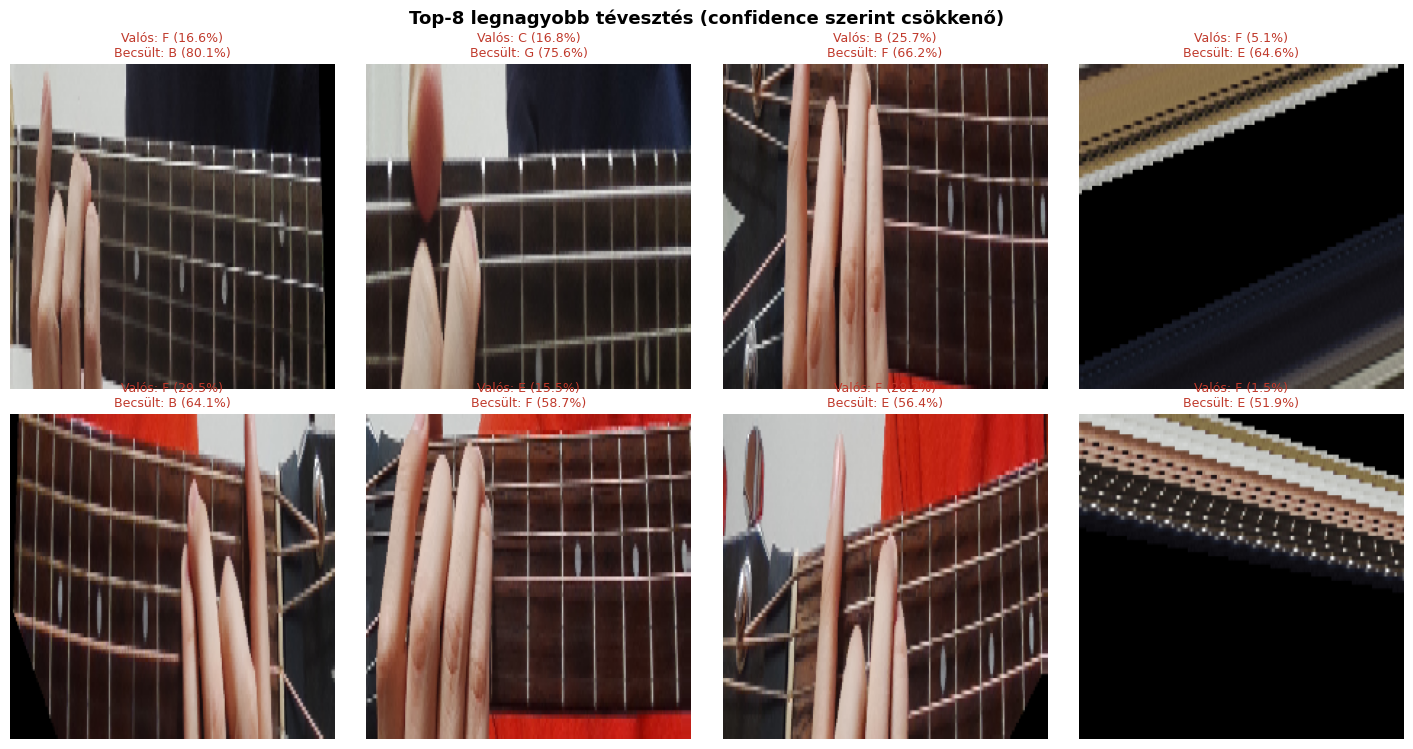

In [14]:
N_SHOW = min(8, len(sorted_err))

if N_SHOW == 0:
    print("Nincs egyetlen tévesztés sem a test seten – kiváló eredmény!")
else:
    n_cols = 4
    n_rows = (N_SHOW + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(n_cols * 3.6, n_rows * 3.8))
    axes_flat = np.array(axes).flatten()

    for ax_i, err_i in enumerate(sorted_err[:N_SHOW]):
        orig_i      = all_orig_i[err_i]
        img         = X_images[orig_i]                      # float32 [0,1] RGB
        true_cls    = classes[all_labels_[err_i]]
        pred_cls    = classes[all_preds_[err_i]]
        confidence  = float(all_probs[err_i, all_preds_[err_i]])
        true_conf   = float(all_probs[err_i, all_labels_[err_i]])

        axes_flat[ax_i].imshow(img)
        axes_flat[ax_i].set_title(
            f"Valós: {true_cls} ({true_conf:.1%})\n"
            f"Becsült: {pred_cls} ({confidence:.1%})",
            color="#c0392b", fontsize=9,
        )
        axes_flat[ax_i].axis("off")

    for ax in axes_flat[N_SHOW:]:
        ax.set_visible(False)

    plt.suptitle(
        f"Top-{N_SHOW} legnagyobb tévesztés (confidence szerint csökkenő)",
        fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

## 8 · Modell Mentése

In [15]:
def _next_version_pth(model_dir: Path, stem: str) -> int:
    """Megkeresi a legmagasabb verziószámot és N+1-et ad vissza."""
    pattern = re.compile(rf"^{re.escape(stem)}_v(\d+)\.pth$")
    versions = [
        int(m.group(1))
        for f in model_dir.iterdir()
        if (m := pattern.match(f.name))
    ]
    return (max(versions) + 1) if versions else 1


v    = _next_version_pth(MODEL_DIR, "cnn_mobilenet_small")
path = MODEL_DIR / f"cnn_mobilenet_small_v{v}.pth"
torch.save(model.state_dict(), path)

print(f"Modell mentve → {path}")
print(f"Test accuracy : {te_acc:.4f}  ({te_acc:.1%})")
print(f"\nBetöltés:")
print(f"  from src.models import build_model")
print(f"  model = build_model('{MODEL_NAME}', num_classes={N_CLASSES})")
print(f"  model.load_state_dict(torch.load('{path.name}', map_location='cpu'))")
print(f"  model.eval()")

Modell mentve → /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/models/cnn_mobilenet_small_v1.pth
Test accuracy : 0.8000  (80.0%)

Betöltés:
  from src.models import build_model
  model = build_model('mobilenet_v3_small', num_classes=8)
  model.load_state_dict(torch.load('cnn_mobilenet_small_v1.pth', map_location='cpu'))
  model.eval()


## Összefoglalás

| | Megjegyzés |
|---|---|
| **Modell** | MobileNetV3-Small, ImageNet pretraining |
| **Adatforrás** | `X_images.npy` – V14 pipeline `canon_norm` kimenet, 224×224 RGB [0,1] |
| **Augmentáció** | ±15° forgatás, [0.75–1.30] fényerő, [0.80–1.20] kontraszt, 50% hflip |
| **Phase A** | Frozen backbone, csak classifier head, lr=1e-3 |
| **Phase B** | Utolsó 3 blokk + head, backbone lr=1e-5, head lr=1e-4 |
| **EarlyStopping** | patience=7 val_loss alapján (mindkét fázisban) |
| **Mentett model** | `models/cnn_mobilenet_small_v{n}.pth` – state_dict |